In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv(
    "../data/processed/features_dataset.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

In [3]:
df.head()

,demand_MW,temperature,time_of_day,is_weekend,season,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_24,...,rolling_mean_168,temp_lag_1,temp_lag_3,temp_lag_24,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-08 00:00:00,32107.0,16.9,Night,0,winter,34384.0,38918.0,50863.0,35720.666667,34891.583333,...,46432.279762,18.8,21.4,12.6,0.000000,1.000000,0.0,1.0,0.5,0.866025
2018-01-08 01:00:00,30797.0,15.9,Night,0,winter,33093.0,37868.0,50587.0,34035.333333,34796.708333,...,46320.636905,16.9,20.3,12.4,0.258819,0.965926,0.0,1.0,0.5,0.866025
2018-01-08 02:00:00,30261.0,16.4,Night,0,winter,32214.0,37441.0,50650.0,32320.000000,34701.041667,...,46202.839286,15.9,18.8,11.9,0.500000,0.866025,0.0,1.0,0.5,0.866025
2018-01-08 03:00:00,30210.0,16.2,Night,0,winter,31731.0,37431.0,50737.0,31055.000000,34619.666667,...,46081.476190,16.4,16.9,11.4,0.707107,0.707107,0.0,1.0,0.5,0.866025
2018-01-08 04:00:00,30763.0,15.8,Night,0,winter,31529.0,37865.0,51021.0,30422.666667,34556.291667,...,45959.291667,16.2,15.9,11.0,0.866025,0.500000,0.0,1.0,0.5,0.866025


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 52416 entries, 2018-01-08 00:00:00 to 2023-12-31 23:00:00
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   demand_MW         52416 non-null  float64
 1   temperature       52416 non-null  float64
 2   time_of_day       52416 non-null  str    
 3   is_weekend        52416 non-null  int64  
 4   season            52416 non-null  str    
 5   lag_24            52416 non-null  float64
 6   lag_48            52416 non-null  float64
 7   lag_168           52416 non-null  float64
 8   rolling_mean_3    52416 non-null  float64
 9   rolling_mean_24   52416 non-null  float64
 10  rolling_std_24    52416 non-null  float64
 11  rolling_mean_168  52416 non-null  float64
 12  temp_lag_1        52416 non-null  float64
 13  temp_lag_3        52416 non-null  float64
 14  temp_lag_24       52416 non-null  float64
 15  hour_sin          52416 non-null  float64
 16  hour_cos        

In [5]:
df.describe()

,demand_MW,temperature,is_weekend,lag_24,lag_48,lag_168,rolling_mean_3,rolling_mean_24,rolling_std_24,rolling_mean_168,temp_lag_1,temp_lag_3,temp_lag_24,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,5.241600e+04,5.241600e+04,5.241600e+04,5.241600e+04,5.241600e+04,5.241600e+04
mean,45855.750591,21.091276,0.285714,45851.487485,45847.585146,45855.407337,45855.456108,45853.765018,5951.532426,45848.397381,21.091279,21.091260,21.092518,-1.558921e-17,-5.693451e-17,-2.060487e-17,-1.518254e-17,-6.601916e-03,-4.925975e-03
std,10582.148965,7.623833,0.451758,10584.721755,10585.922276,10591.570433,10478.349489,8372.558074,2882.124163,7907.845596,7.623832,7.623833,7.621967,7.071135e-01,7.071135e-01,7.071135e-01,7.071135e-01,7.062728e-01,7.079053e-01
min,27371.000000,-10.900000,0.000000,27371.000000,27371.000000,27371.000000,27507.333333,32081.625000,848.898720,33767.470238,-10.900000,-10.900000,-10.900000,-1.000000e+00,-1.000000e+00,-9.749279e-01,-9.009689e-01,-1.000000e+00,-1.000000e+00
25%,38302.000000,16.100000,0.000000,38292.750000,38286.750000,38285.000000,38351.666667,39101.343750,3341.437151,39460.441964,16.100000,16.100000,16.100000,-7.071068e-01,-7.071068e-01,-7.818315e-01,-9.009689e-01,-8.660254e-01,-8.660254e-01
50%,43279.000000,22.500000,0.000000,43273.000000,43267.000000,43262.500000,43290.000000,44139.958333,5165.870079,43776.309524,22.500000,22.500000,22.500000,6.123234e-17,-6.123234e-17,0.000000e+00,-2.225209e-01,-2.449294e-16,-1.836970e-16
75%,51292.250000,26.500000,1.000000,51292.250000,51290.000000,51341.500000,51262.833333,51828.625000,8736.252010,51624.169643,26.500000,26.500000,26.500000,7.071068e-01,7.071068e-01,7.818315e-01,6.234898e-01,5.000000e-01,5.000000e-01
max,85432.000000,41.700000,1.000000,85432.000000,85432.000000,85432.000000,85043.333333,71795.208333,13427.117014,70245.404762,41.700000,41.700000,41.700000,1.000000e+00,1.000000e+00,9.749279e-01,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
df.index.min(), df.index.max()

(Timestamp('2018-01-08 00:00:00'), Timestamp('2023-12-31 23:00:00'))

In [7]:
train = df.loc[: "2021-12-31"]
val = df.loc["2022-01-01" : "2022-12-31"]
test = df.loc["2023-01-01" :]   

In [8]:
print(f"Train shape: {train.shape}")
print(f"Validation shape: {val.shape}")
print(f"Test shape: {test.shape}")

Train shape: (34896, 21)
Validation shape: (8760, 21)
Test shape: (8760, 21)


In [9]:
# Splitting into features and target
# The target variable is 'demand_MW' and the rest are features.
X_train = train.drop(columns=["demand_MW"])
y_train = train["demand_MW"]

X_val = val.drop(columns=["demand_MW"])
y_val = val["demand_MW"]

X_test = test.drop(columns=["demand_MW"])
y_test = test["demand_MW"]

## Baseline Model: Seasonal Naive Forecast

To establish a benchmark for model performance, we first implement a **seasonal naive baseline**.

Electricity demand typically exhibits strong **daily seasonality**, meaning that demand at a given hour is often similar to the demand observed at the same hour on the previous day.

The seasonal naive forecast assumes:

demand(t) = demand(t−24)

where:
- demand(t) is the predicted demand at time \( t \)
- demand(t−24) is the observed demand from the same hour on the previous day

This baseline captures the dominant daily pattern in electricity consumption and serves as a strong reference point.

Any machine learning model developed later must **outperform this baseline** to demonstrate meaningful predictive value.

In [10]:
# Baseline model: Using the demand from 24 hours ago (lag_24) as the prediction for the current hour.
baseline_val_pred = X_val["lag_24"]
baseline_test_pred = X_test["lag_24"]

In [11]:
# Evaluate the baseline model using Mean Absolute Error (MAE)
mae_val = mean_absolute_error(y_val, baseline_val_pred)
mae_test = mean_absolute_error(y_test, baseline_test_pred)

print("Validation MAE:", mae_val)
print("Test MAE:", mae_test)

Validation MAE: 2631.655821917808
Test MAE: 2298.790410958904


In [12]:
# Evaluate the baseline model using Mean Absolute Percentage Error (MAPE)
mape = (abs((y_test - baseline_test_pred) / y_test)).mean() * 100
print("Test MAPE:", mape)

Test MAPE: 4.655459768789845


## Baseline Model Evaluation

To assess forecasting performance, we evaluate the seasonal naive baseline using **Mean Absolute Error (MAE)** and **Mean Absolute Percentage Error (MAPE)**.

### Results

| Metric         | Value    |
| -------------- | -------- |
| Validation MAE | ~2631 MW |
| Test MAE       | ~2299 MW |
| Test MAPE      | ~4.65%   |

### Interpretation

The seasonal naive baseline achieves a **test MAE of approximately 2300 MW** and a **MAPE of around 4.65%**, indicating that daily electricity demand patterns are highly persistent.

Simply repeating the demand observed at the same hour on the previous day already produces a reasonably accurate forecast. This reflects the strong **daily seasonality** present in electricity consumption.

However, the baseline model does not account for additional factors that influence demand, such as:

* temperature fluctuations
* weekly demand variations (e.g., weekends vs weekdays)
* nonlinear relationships between weather and demand

### Implications

More advanced machine learning models should aim to improve upon this baseline by incorporating **calendar features, lagged demand values, and weather variables**, allowing the model to capture patterns that extend beyond simple daily repetition.


## Baseline Forecast vs Actual Demand

To visually assess baseline performance, we compare the **seasonal naive forecast** with the actual electricity demand over a short time window.

The plot below shows two weeks of demand from the test set.  
The baseline prediction simply repeats the demand observed **24 hours earlier**.

This visualization helps illustrate how well the baseline captures the **daily demand cycle**, while also revealing situations where it struggles, such as:

- sudden demand spikes
- weather-driven demand changes
- atypical demand patterns

This comparison provides an intuitive understanding of the baseline model's strengths and limitations.

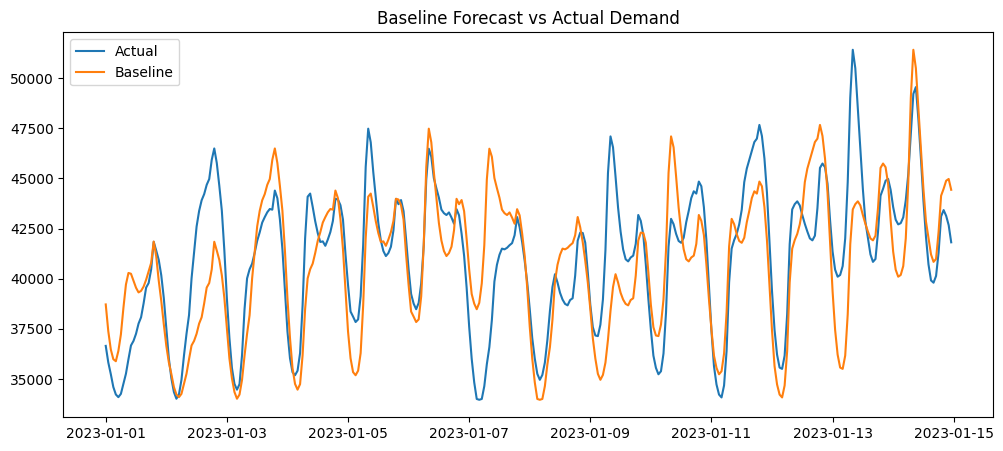

In [13]:
# Visualize the baseline predictions vs actual demand for a subset of the test set
subset = y_test.loc["2023-01-01":"2023-01-14"]

plt.figure(figsize=(12,5))
plt.plot(subset.index, subset, label="Actual")
plt.plot(subset.index, baseline_test_pred.loc[subset.index], label="Baseline")
plt.legend()
plt.title("Baseline Forecast vs Actual Demand")
plt.show()

## Baseline Forecast Errors

To further evaluate the baseline model, we examine the **forecast errors** defined as:

errors = y_test - baseline_test_pred

Plotting the errors over time helps identify systematic patterns such as:

- periods where the baseline consistently underpredicts demand
- periods where demand spikes are not captured by the naive forecast
- unusual demand events caused by weather or behavioral changes

Understanding these error patterns helps motivate the need for more advanced models that incorporate additional predictors such as weather variables, calendar effects, and nonlinear relationships.

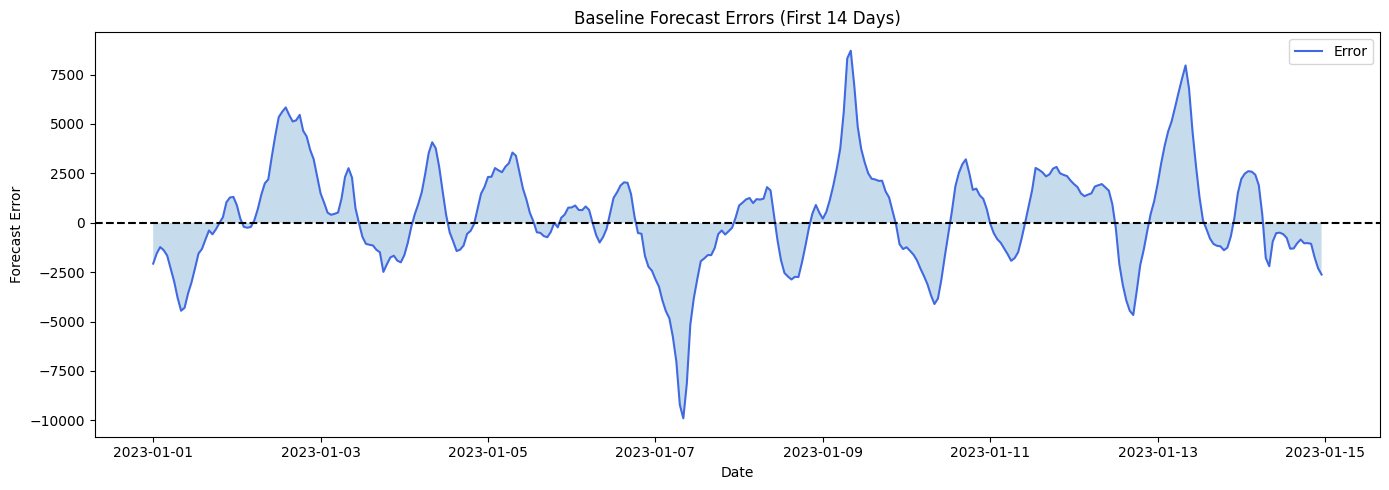

In [14]:
errors = y_test - baseline_test_pred
subset = errors.loc["2023-01-01":"2023-01-14"]

plt.figure(figsize=(14,5))

plt.plot(subset, color="royalblue", label="Error")

plt.fill_between(subset.index, subset, 0, alpha=0.25)

plt.axhline(0, color="black", linestyle="--")

plt.title("Baseline Forecast Errors (First 14 Days)")
plt.ylabel("Forecast Error")
plt.xlabel("Date")

plt.legend()

plt.tight_layout()
plt.show()

## Baseline Performance Summary

The seasonal naive baseline achieves the following performance:

- **Validation MAE:** ~2631 MW  
- **Test MAE:** ~2299 MW  
- **Test MAPE:** ~4.65%

These results indicate that daily electricity demand patterns are highly persistent. Simply repeating the previous day's demand already produces a reasonably accurate forecast.

However, the baseline cannot account for factors such as:
- temperature fluctuations
- changing weekly patterns
- nonlinear interactions between predictors

In the next section, we explore machine learning models to determine whether they can **improve upon this strong baseline**.